In [1]:
# !pip install --upgrade timm -q
# !pip install --upgrade segmentation_models_pytorch -q
# !pip install pytorch_lightning -q
# !pip install albumentations -q
# !pip install matplotlib -q
# !pip install pandarallel -q
# !pip install einops
# !pip install -U tensorboard

In [2]:
!nvidia-smi

Fri Oct 20 20:54:05 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.125.06   Driver Version: 525.125.06   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA RTX A6000    On   | 00000000:01:00.0 Off |                  Off |
| 30%   38C    P8    27W / 300W |      1MiB / 49140MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA RTX A6000    On   | 00000000:22:00.0 Off |                  Off |
| 30%   

In [3]:
# Change image size limit before import opencv
import os
# os.environ["OPENCV_IO_MAX_IMAGE_PIXELS"] = pow(2,40).__str__()

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
from torchmetrics import Accuracy
import datetime
from sklearn.model_selection import StratifiedKFold

import gc
import cv2
import timm
from PIL import Image
from matplotlib import pyplot as plt
import argparse
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from pandarallel import pandarallel

pandarallel.initialize(use_memory_fs=False, nb_workers=os.cpu_count(), progress_bar=True)

INFO: Pandarallel will run on 64 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


In [4]:
set([x.split('_')[0].split('.')[0] for x in timm.list_models('*', pretrained=True)])

# timm.list_models('*resnet*', pretrained=True)

{'SelecSls42b',
 'SelecSls60',
 'SelecSls60b',
 'bat',
 'beit',
 'beitv2',
 'botnet26t',
 'caformer',
 'cait',
 'coat',
 'coatnet',
 'coatnext',
 'convformer',
 'convit',
 'convmixer',
 'convnext',
 'convnextv2',
 'crossvit',
 'cs3darknet',
 'cs3edgenet',
 'cs3se',
 'cs3sedarknet',
 'cspdarknet53',
 'cspresnet50',
 'cspresnext50',
 'darknet53',
 'darknetaa53',
 'davit',
 'deit',
 'deit3',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'densenetblur121d',
 'dla102',
 'dla102x',
 'dla102x2',
 'dla169',
 'dla34',
 'dla46',
 'dla46x',
 'dla60',
 'dla60x',
 'dm',
 'dpn107',
 'dpn131',
 'dpn68',
 'dpn68b',
 'dpn92',
 'dpn98',
 'eca',
 'ecaresnet101d',
 'ecaresnet269d',
 'ecaresnet26t',
 'ecaresnet50d',
 'ecaresnet50t',
 'ecaresnetlight',
 'edgenext',
 'efficientformer',
 'efficientformerv2',
 'efficientnet',
 'efficientnetv2',
 'ese',
 'eva',
 'eva02',
 'fbnetc',
 'fbnetv3',
 'flexivit',
 'focalnet',
 'gc',
 'gcresnet33ts',
 'gcresnet50t',
 'gcresnext26ts',
 'gcresnext50ts'

In [5]:
args = dict(
    seed=42,
    model='efficientnet_b4',
    lr=1e-3, #5e-5,
    weight_decay=0.1,
    log_dir='logs_small',
    num_workers=min(8, os.cpu_count()),
    epochs=10, #200,
    batch_size=16, #32,
    accumulate_grad_batches=1,
    image_size=1024, #512,
    gpus='1',
    patience=20, #5,
    precision='16-mixed',
    scheduler='onecycle', #'plateau', #'onecycle',
    n_splits=5,
    gem_p=3.0, #1.0,
    dropout=0.5, #0.0,
    repeats=2,
    num_tiles=16,
    tile_size=256, #224|256|384|512
    add_other_cls=False, #True,
)

args = argparse.Namespace(**args)

In [6]:
!ls

NGC-DL-CONTAINER-LICENSE       lib32		       sbin
UBC-OCEAN.zip		       lib64		       srv
UBC-Training-Small-Tile.ipynb  libs_install_ubc.ipynb  sys
UBC-Training-Small.ipynb       libx32		       tmp
bin			       logs_small	       train.csv
boot			       media		       train_bbox.csv
dev			       mnt		       ubc-small
etc			       opt		       ubc-small.zip
home			       proc		       usr
influxdb2-2.0.4-amd64.deb      root		       var
kaggle.json		       run		       workspace
lib			       sample_submission.csv


In [7]:
# BASE_PATH = 'images/'
BASE_PATH = 'ubc-small/small/'

In [8]:
df_train = pd.read_csv('train.csv')

df_train['img_path'] = df_train['image_id'].apply(lambda image_id: f"{BASE_PATH}/{image_id}.png")

In [9]:
# df_train = pd.read_csv('train_bbox.csv')

In [10]:
df_train.shape

(538, 6)

In [11]:
df_train.head()

,image_id,label,image_width,image_height,is_tma,img_path
0,4,HGSC,23785,20008,False,ubc-small/small//4.png
1,66,LGSC,48871,48195,False,ubc-small/small//66.png
2,91,HGSC,3388,3388,True,ubc-small/small//91.png
3,281,LGSC,42309,15545,False,ubc-small/small//281.png
4,286,EC,37204,30020,False,ubc-small/small//286.png


In [12]:
df_train.dtypes

image_id         int64
label           object
image_width      int64
image_height     int64
is_tma            bool
img_path        object
dtype: object

In [13]:
df_train['label'].value_counts() #normalize=True) ** -1

label
HGSC    222
EC      124
CC       99
LGSC     47
MC       46
Name: count, dtype: int64

In [14]:
cls_df = (df_train['label'].value_counts(normalize=True) ** -1).to_frame().reset_index()

if args.add_other_cls:
    cls_df = pd.concat(
        [cls_df, pd.DataFrame([['Other', cls_df.proportion.max()*1.5]], columns=['label', 'proportion'])],
        axis=0,
        ignore_index=True,
    )

cls_df['proportion'] /= cls_df['proportion'].min()
cls_df

,label,proportion
0,HGSC,1.000000
1,EC,1.790323
2,CC,2.242424
3,LGSC,4.723404
4,MC,4.826087


In [15]:
cls_map = cls_df.reset_index().set_index('label')[['index']].to_dict()['index']
cls_map

{'HGSC': 0, 'EC': 1, 'CC': 2, 'LGSC': 3, 'MC': 4}

In [16]:
cls_map_inv = cls_df[['label']].to_dict()['label']
cls_map_inv

{0: 'HGSC', 1: 'EC', 2: 'CC', 3: 'LGSC', 4: 'MC'}

In [17]:
cls_weights = torch.tensor(cls_df['proportion'].values).float()
cls_weights

tensor([1.0000, 1.7903, 2.2424, 4.7234, 4.8261])

In [18]:
# cls_map = {key: index for index, key in enumerate(['CC', 'EC', 'HGSC', 'LGSC', 'MC', 'Other'])}

# cls_map_inv = {index: key for index, key in enumerate(['CC', 'EC', 'HGSC', 'LGSC', 'MC', 'Other'])}

In [19]:
args.num_classes  = len(cls_weights)

In [20]:
pd.read_csv('sample_submission.csv')

,image_id,label
0,41,HGSC


In [21]:
import numpy as np
import cv2


def get_mask(image):
    # using BGR2GRAY on RGB work best for the tma
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#     gray = rgb2gray(image)
    
    # get corner values for segmentation
    h, w = gray.shape
    h1 = h//100
    w1 = w//100
    corner_values = np.mean([gray[:h1, :w1], gray[-h1:, :w1], gray[:h1, -w1:], gray[-h1:, -w1:]], axis=0).mean()
    
    # get the mask
    if corner_values > 128:
        corner_values = 255 - corner_values
        gray = 255 - gray

    mask = np.abs(gray-corner_values) > corner_values
    return mask.astype('uint8')


def get_patch_bbox(mask, CROP_SIZE=224, OVERLAP=64):
    H, W = mask.shape
    bboxes = []
    probs = []
    for y in range(0, H-CROP_SIZE+1, CROP_SIZE-OVERLAP):
        for x in range(0, W-CROP_SIZE+1, CROP_SIZE-OVERLAP):
            bbox = [x, y, x+CROP_SIZE, y+CROP_SIZE]
            prob = mask[bbox[1]:bbox[3], bbox[0]:bbox[2]].mean()
            bboxes.append(bbox)
            probs.append(prob)
#             if  prob > 0.5:
#                 bboxes.append(bbox)
    return np.array(bboxes), np.array(probs)


def get_all_patches(img_path):
    mask = get_mask(np.array(Image.open(img_path)))
    result = dict()
    for CROP_SIZE in [224, 256, 384, 512]:
        bboxes, probs = get_patch_bbox(mask, CROP_SIZE=CROP_SIZE, OVERLAP=CROP_SIZE//4)
        sort_order = probs.argsort()[::-1]
        bboxes = bboxes[sort_order]
        probs = probs[sort_order]
        result.update({
            f'bboxes{CROP_SIZE}': bboxes,
            f'probs{CROP_SIZE}': probs
        })
    return result

In [22]:
%%time

results = df_train.img_path.parallel_apply(get_all_patches)
df_train = pd.concat([df_train, pd.DataFrame.from_records(results)], axis=1)
count = df_train[df_train.columns[df_train.columns.str.startswith('bboxes')]].applymap(len)
count.columns = [column.replace('bboxes', 'count') for column in count]
df_train = pd.concat([df_train, count], axis=1)
df_train

# df_train.to_csv('train_bbox.csv', index=False)

CPU times: user 1.17 s, sys: 897 ms, total: 2.06 s
Wall time: 1min 10s


,image_id,label,image_width,image_height,is_tma,img_path,bboxes224,probs224,bboxes256,probs256,bboxes384,probs384,bboxes512,probs512,count224,count256,count384,count512
0,4,HGSC,23785,20008,False,ubc-small/small//4.png,"[[336, 336, 560, 560], [1848, 1176, 2072, 1400...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[[1920, 1152, 2176, 1408], [384, 1152, 640, 14...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[[1440, 1152, 1824, 1536], [288, 864, 672, 124...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[[1152, 1152, 1664, 1664], [1920, 1152, 2432, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",238,180,80,42
1,66,LGSC,48871,48195,False,ubc-small/small//66.png,"[[1344, 1344, 1568, 1568], [1512, 1176, 1736, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[[1344, 1344, 1600, 1600], [1536, 1728, 1792, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[[1152, 1152, 1536, 1536], [1440, 1152, 1824, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[[1152, 1152, 1664, 1664], [1536, 1536, 2048, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",289,225,90,49
2,91,HGSC,3388,3388,True,ubc-small/small//91.png,"[[1344, 1680, 1568, 1904], [1512, 1680, 1736, ...","[0.9839963329081632, 0.9706831951530612, 0.969...","[[1920, 1728, 2176, 1984], [2304, 2304, 2560, ...","[0.9739227294921875, 0.9687957763671875, 0.968...","[[1152, 1728, 1536, 2112], [1440, 1728, 1824, ...","[0.9426337348090278, 0.9408976236979166, 0.920...","[[1920, 1536, 2432, 2048], [1920, 1920, 2432, ...","[0.9118499755859375, 0.9016914367675781, 0.888...",361,289,121,64
3,281,LGSC,42309,15545,False,ubc-small/small//281.png,"[[336, 504, 560, 728], [672, 504, 896, 728], [...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[[2496, 192, 2752, 448], [384, 384, 640, 640],...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.989...","[[2304, 288, 2688, 672], [288, 288, 672, 672],...","[0.9896443684895834, 0.9687432183159722, 0.925...","[[2304, 384, 2816, 896], [384, 384, 896, 896],...","[0.9277267456054688, 0.9205513000488281, 0.790...",102,75,30,14
4,286,EC,37204,30020,False,ubc-small/small//286.png,"[[2688, 1008, 2912, 1232], [1680, 840, 1904, 1...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[[1920, 1152, 2176, 1408], [2304, 1344, 2560, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[[576, 1152, 960, 1536], [864, 1440, 1248, 182...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[[1152, 768, 1664, 1280], [1152, 1152, 1664, 1...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",238,180,80,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
533,65022,LGSC,53355,46675,False,ubc-small/small//65022.png,"[[672, 168, 896, 392], [1512, 336, 1736, 560],...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[[768, 1344, 1024, 1600], [768, 1728, 1024, 19...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[[576, 1152, 960, 1536], [1728, 864, 2112, 124...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[[1920, 1152, 2432, 1664], [1920, 1536, 2432, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",255,195,80,42
534,65094,MC,55042,45080,False,ubc-small/small//65094.png,"[[1680, 1176, 1904, 1400], [1848, 1008, 2072, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[[1536, 1152, 1792, 1408], [1728, 960, 1984, 1...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[[1440, 1152, 1824, 1536], [864, 1440, 1248, 1...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[[384, 1152, 896, 1664], [1152, 1536, 1664, 20...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",238,180,80,42
535,65300,HGSC,75860,27503,False,ubc-small/small//65300.png,"[[2688, 336, 2912, 560], [2520, 504, 2744, 728...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[[384, 576, 640, 832], [2496, 576, 2752, 832],...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[[576, 288, 960, 672], [2304, 288, 2688, 672],...","[1.0, 1.0, 1.0, 0.9999525282118056, 0.97420925...

In [23]:
# [mask[bbox[1]:bbox[3], bbox[0]:bbox[2]] for bbox in bboxes]

In [24]:
# df_train.probs224.apply(lambda x: (x>0.05).sum()).sort_values()

In [25]:
# df_train.iloc[266]['probs512']

In [26]:
# from scipy.special import softmax

In [27]:
# df_train.iloc[266]['probs512'] / df_train.iloc[266]['probs512'].sum()

In [28]:
# np.random.choice(a, size=None, replace=True, p=None)

In [29]:
# np.tile(np.arange(5), 16//5 + 1).shape

In [30]:
from functools import reduce

def factors(n):    
    return set(reduce(list.__add__, 
                ([i, n//i] for i in range(1, int(n**0.5) + 1) if n % i == 0)))


def get_values(n):
    f = np.array(list(factors(n)))
    mid = len(f) // 2
    if len(f)//2 != len(f)/2:
        locs = [mid, mid]
    else:
        locs = [mid, mid+1]
    return f[locs].tolist()

In [31]:
# factors(16), factors(12)

In [32]:
# np.array(list(factors(16)))[[2,3]]

In [33]:
# get_values(24)

In [34]:
class UBCDataset(Dataset):
    def __init__(self, df, transforms=None, repeats=1, tile_size=224, is_train=False, num_tiles=16):
        assert tile_size in [224, 256, 384, 512]
        self.ids = df['image_id'].tolist()
        self.img_paths = df['img_path'].tolist()
        self.bboxes = df[f'bboxes{tile_size}']
        self.probs = df[f'probs{tile_size}']
        self.is_train = is_train
        self.num_tiles = num_tiles
        self.transforms = transforms
        self.repeats = repeats
        if 'label' in df.columns:
            self.labels = df['label'].tolist()
        
    def __len__(self):
        return len(self.ids) * self.repeats
    
    def __getitem__(self, idx):
        idx = idx % len(self.ids)
        
        _id = self.ids[idx]
        img_path = self.img_paths[idx]
        img = cv2.imread(img_path,cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #[min_row:max_row, min_col:max_col]
        
        if self.is_train:
            n = np.random.choice(
                len(self.probs[idx]), 
                size=self.num_tiles,
                replace=True, 
                p=self.probs[idx]/self.probs[idx].sum(),
            )
        else:
            n_valid = len(self.probs[idx][self.probs[idx] > 0]) #0.25*self.probs[idx].max()])
            n = np.tile(np.arange(n_valid), self.num_tiles//n_valid + 1)[:self.num_tiles]
        bboxes = self.bboxes[idx][n]
        probs = self.probs[idx][n]
        if img.shape[-1] != 3:
            img = torch.stack([img[:, bbox[1]:bbox[3], bbox[0]:bbox[2]] for bbox in bboxes])
        else:
            img = np.stack([img[bbox[1]:bbox[3], bbox[0]:bbox[2]] for bbox in bboxes])
        
        if self.transforms is not None:
#             img = self.transforms(image=img)['image']
#             transformed = self.transforms(
#                 **{
#                     f'image{k}': img[k] for k in range(self.num_tiles)
#                 }
#             )
#             img = torch.stack([transformed[f'image{k}'] for k in range(self.num_tiles)])
            img = torch.stack([self.transforms(image=img[k])['image'] for k in range(self.num_tiles)])
        
        sample = dict(
            image_id=_id,
            image=img,
            probs=probs,
        )
        
        if hasattr(self, 'labels'):
            sample['label'] = cls_map[self.labels[idx]]
            
        return sample

In [35]:
def get_transforms(train=False, image_size=512, debug=False): #, num_tiles=16):
#     augmentations = [
#         A.LongestMaxSize(max_size=image_size),
#         A.PadIfNeeded(min_height=image_size, min_width=image_size, border_mode=3),
#     ]
    augmentations = []
    if train:
        augmentations.extend([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.Transpose(p=0.5),
#             A.RandomShadow (p=0.5),
#             A.RandomSunFlare(p=0.5),
#             A.GaussianBlur(blur_limit=(3, 7), sigma_limit=[0.1, 3], p=0.5),
            A.RandomBrightnessContrast(
                brightness_limit=0.2, contrast_limit=0.2, brightness_by_max=True, p=0.3),
#             A.ShiftScaleRotate(shift_limit=0, scale_limit=(-0.5, -0.1), rotate_limit=0, border_mode=0, p=0.5),  # added Mar 2
            A.ColorJitter(p=0.5),
            A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.25),
        ])
    
    if not debug:
        augmentations.append(
            A.Normalize(
                mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225), 
                max_pixel_value=255.0,
            ),  # using basic imagenet statistics (default)
        )
    augmentations.extend([
        ToTensorV2(),
    ])
    
    transforms = A.Compose(
        augmentations,
#         additional_targets={f'image{k}': 'image' for k in range(num_tiles)}
    )
    
    return transforms

In [36]:
def plot_sample(dst, idx=None):
    if idx is None:
        idx = np.random.randint(len(dst), size=(1,))[0]
    
    sample = dst[idx]
    images = sample['image']
    if images.shape[1] == 3:
        images = images.permute(0,2,3,1)
    
    r, c = get_values(images.shape[0]) # get factors
    
    _, axes = plt.subplots(r, c, figsize=(c*5, r*5))
    axes = axes.flatten()
    
    title = str(sample['image_id'])
    if 'label' in sample.keys():
        title += f': {cls_map_inv[sample["label"]]}'
        
    for k in range(images.shape[0]):
        image = images[k]
        if images.shape[0] == 3:
            image = image.permute(1,2,0)
        axes[k].imshow(image)
        prob = sample['probs'][k]
        axes[k].set_title(f"{title} : {prob: 0.4f}")

In [37]:
# trf = get_transforms(train=True)

In [38]:
# trf

In [39]:
# trf.additional_targets

In [40]:
# dst = UBCDataset(df_train)
dst = UBCDataset(df_train, is_train=True, transforms=get_transforms(train=True, debug=True), num_tiles=25, tile_size=224)

In [41]:
sample = dst[14]

In [42]:
sample.keys()

dict_keys(['image_id', 'image', 'probs', 'label'])

In [43]:
# sample['image'].shape

In [44]:
# plt.imshow(sample['image'])

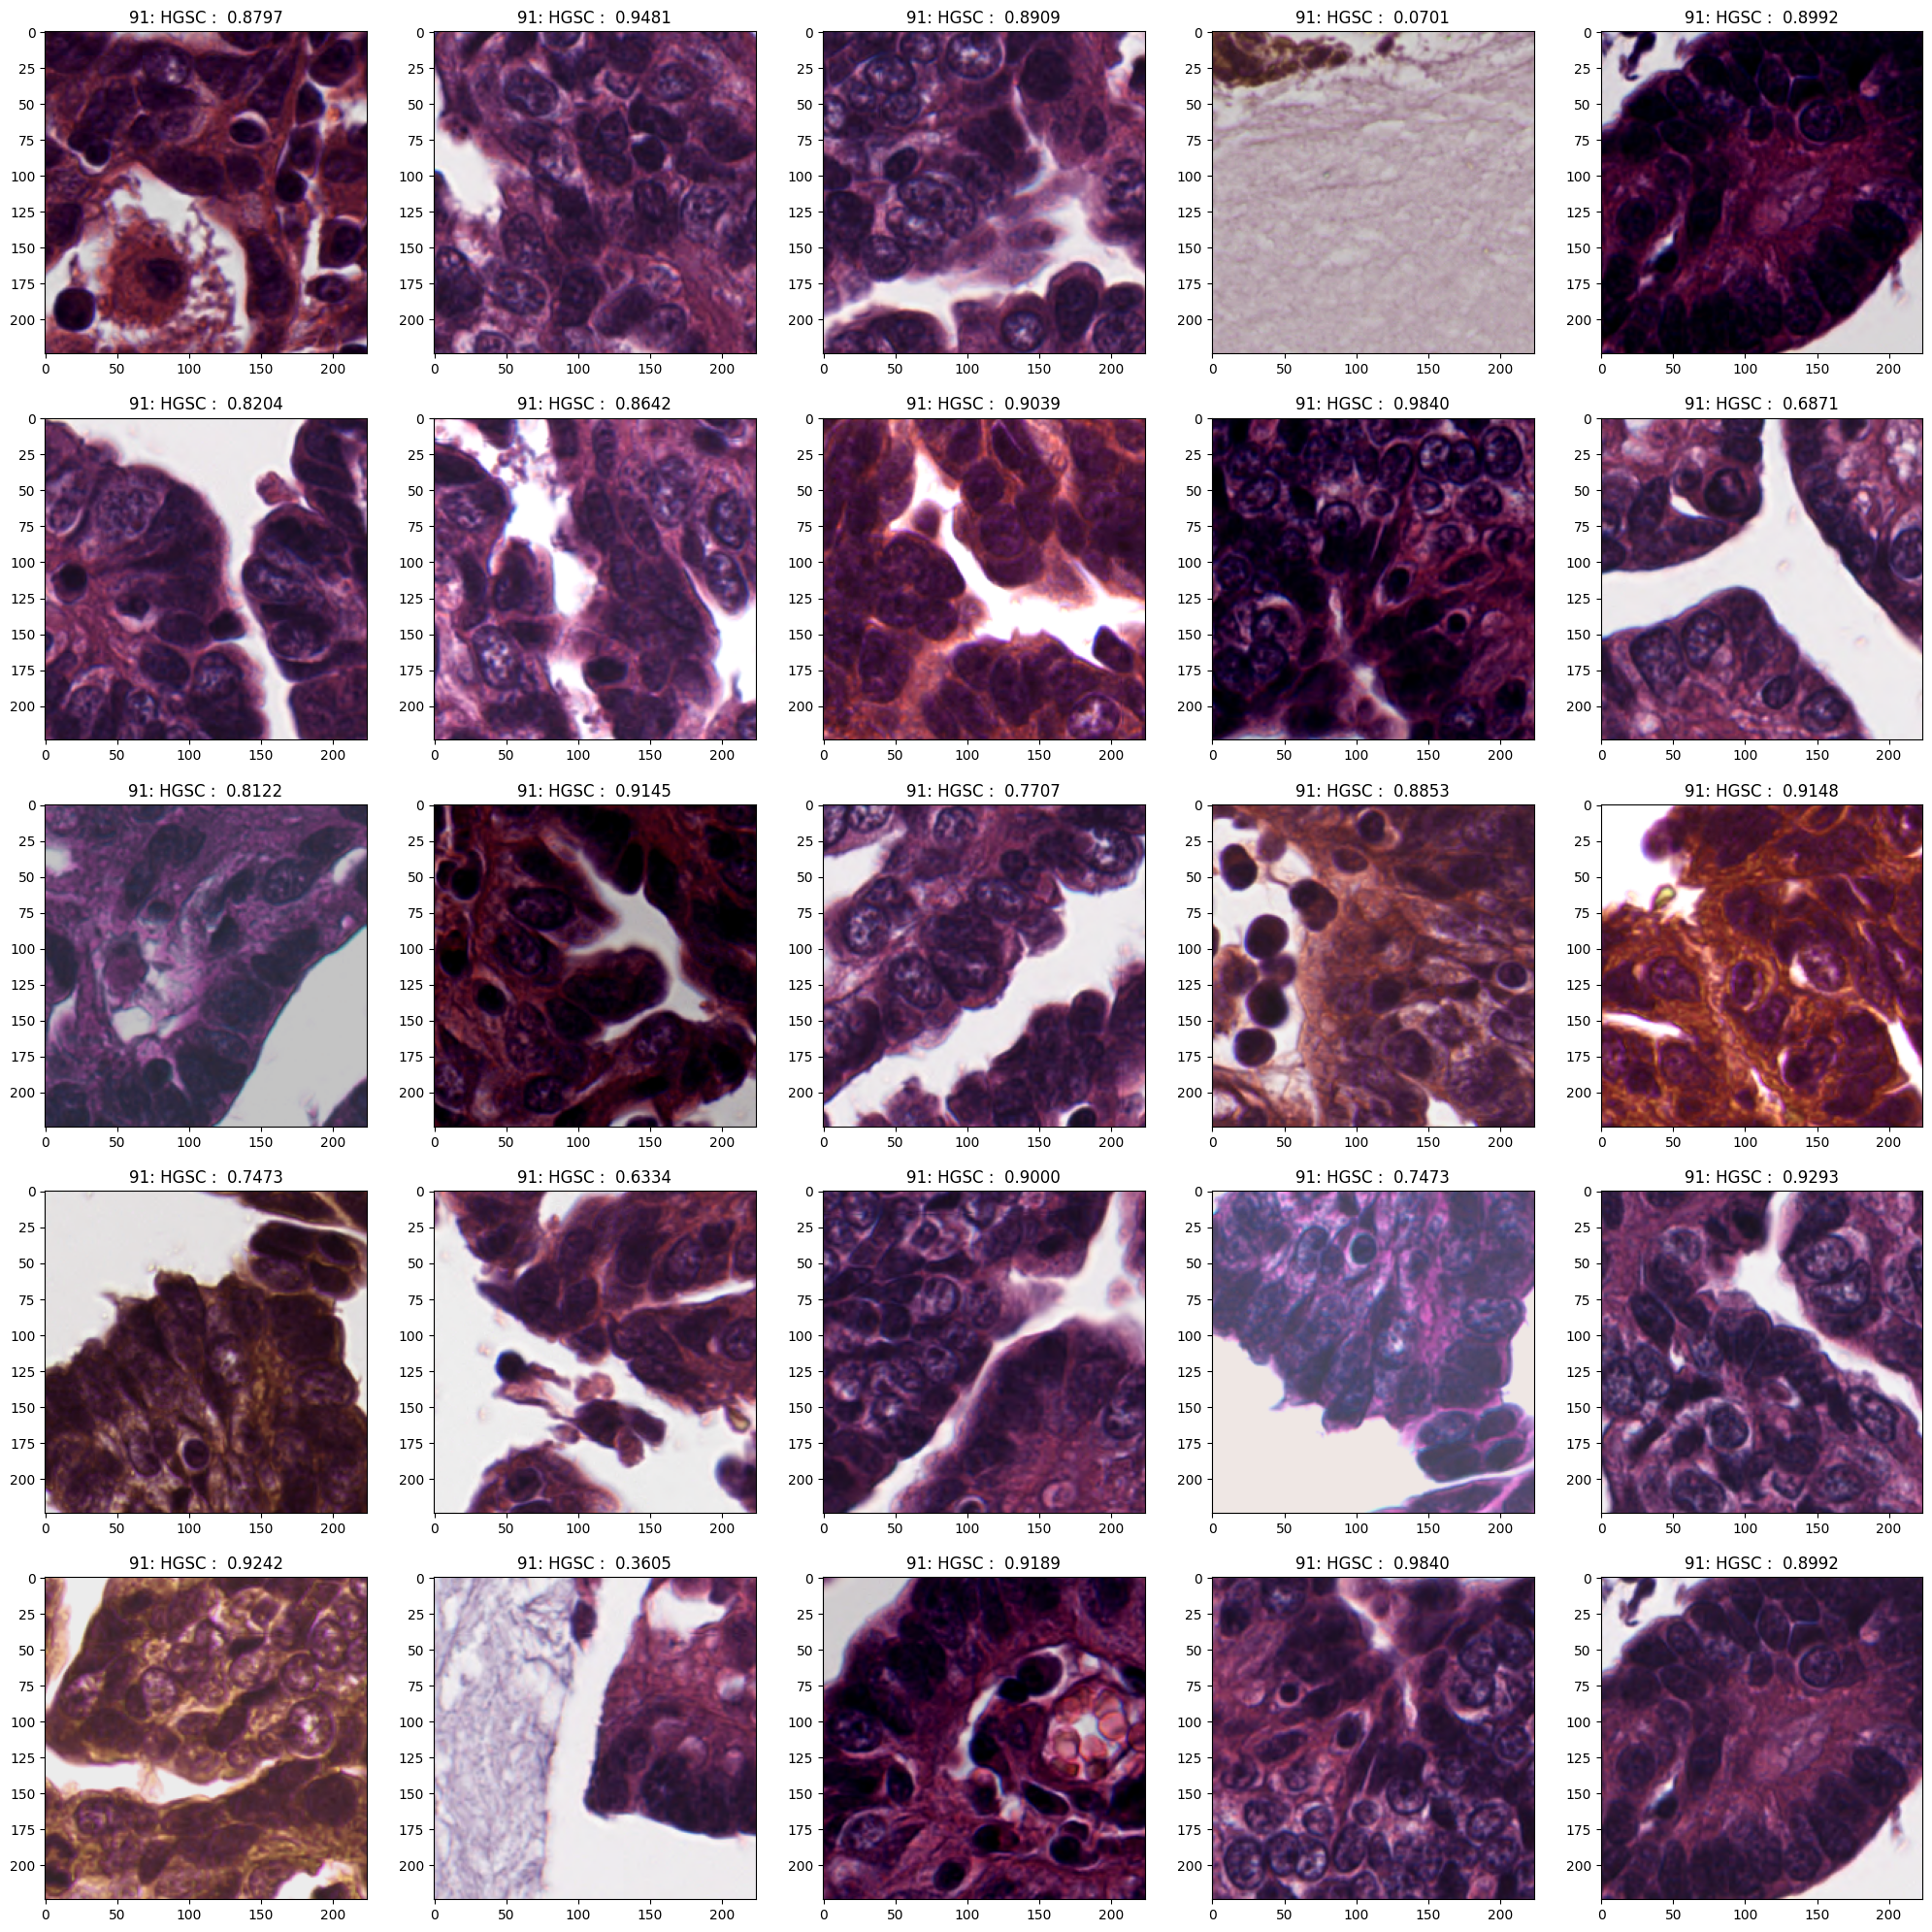

In [45]:
plot_sample(dst, 2)

In [46]:
# factors(16)

In [47]:
# dst = UBCDataset(df_train, transforms=get_transforms(train=True, image_size=256, debug=True))

In [48]:
# plot_sample(dst, 14)

In [49]:
del dst
gc.collect()

83132

In [50]:
from functools import wraps
import gc

def flush_and_gc(f):
    @wraps(f)
    def g(*args, **kwargs):
        torch.cuda.empty_cache()
        gc.collect()
        return f(*args, **kwargs)
    return g

In [51]:
import torch.nn.functional as F
from torch.nn.parameter import Parameter


def gem(x, p=1, eps=1e-6):
    return F.avg_pool2d(x.clamp(min=eps).pow(p), (x.size(-2), x.size(-1))).pow(1.0 / p)


class GeM(nn.Module):
    def __init__(self, p=1, eps=1e-6, flatten=True):
        super(GeM, self).__init__()
        self.p = Parameter(torch.ones(1) * p)
        self.eps = eps
        self.flatten = flatten

    def forward(self, x):
        ret = gem(x, p=self.p, eps=self.eps)
        if self.flatten:
            return ret.flatten(1)
        return ret

    def __repr__(self):
        return (
                self.__class__.__name__
                + "("
                + "p="
                + "{:.4f}".format(self.p.data.tolist()[0])
                + ", "
                + "eps="
                + str(self.eps)
                + ")"
        )

In [52]:
from einops import rearrange, reduce as ein_reduce


def init_layer(layer):
    nn.init.xavier_uniform_(layer.weight)

    if hasattr(layer, "bias"):
        if layer.bias is not None:
            layer.bias.data.fill_(0.)
            
            
class TileModel(nn.Module):
    def __init__(self, model_name='resnet34',
                 num_classes=6, dropout=0.0, gem_p=1.0):
        super().__init__()
        
        self.backbone = timm.create_model(model_name, pretrained=True, num_classes=0, global_pool='')
        
        self.pool = GeM(p=gem_p)
        
        self.dropout = nn.Dropout(p=dropout)
        self.num_features = self.backbone.num_features
        self.fc = nn.Linear(self.backbone.num_features, num_classes)
        init_layer(self.fc)
        
    def forward(self, x):
        x = self.backbone(x)
#         print(x.shape)
        if x.shape[1] != self.num_features:
            x = rearrange(x, 'b h w c -> b c h w')
        x = self.pool(x)  # B F 1
        # dropout first
        x = self.dropout(x)
        out = self.fc(x)
        
        return out
    

class CustomLoss(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.dice = smp.losses.DiceLoss(mode='multiclass', classes=num_classes, smooth=0.1)
        self.focal = smp.losses.FocalLoss(mode='multiclass', alpha=None, gamma=2.0, normalized=True)
        self.entropy = nn.CrossEntropyLoss(label_smoothing=0.1, weight=cls_weights)
    
    def forward(self, pred, label):
        dice = self.dice(pred, label)
        focal = self.focal(pred, label)
        entropy = self.entropy(pred, label)
        
        loss = dice + focal + entropy
        return loss
    
    
class UBCModel(pl.LightningModule):
    def __init__(self, args):
        super().__init__()
        self.save_hyperparameters()
        
        num_classes = args.num_classes
        self.net = TileModel(args.model, num_classes, args.dropout, args.gem_p)   

#         self.criterion = nn.CrossEntropyLoss(label_smoothing=0.1, weight=cls_weights)
#         self.criterion = smp.losses.DiceLoss(mode='multiclass', classes=5, smooth=0.1)
#         self.criterion = smp.losses.FocalLoss(mode='multiclass', alpha=None, gamma=2.0, normalized=True)
        self.criterion = CustomLoss(num_classes)
        self.accuracy = Accuracy(task='multiclass', num_classes=num_classes, average='macro')  #balanced
        
    def forward(self, image):
        b = image.shape[0]
        if image.ndim == 5:
            image = rearrange(image, 'b n c h w -> (b n) c h w')
        out = self.net(image)
        out = ein_reduce(out, '(b n) c -> b c', reduction='mean', b=b)
        return out #self.net(image)
    
#     @flush_and_gc
    def training_step(self, batch, batch_idx=0):
        image = batch['image']
        label = batch['label']
        
        pred = self(image)
        
        loss = self.criterion(pred, label)
        acc = self.accuracy(pred, label)
        
        self.log('lr', self.optimizers().param_groups[0]['lr'], prog_bar=True)
        self.log('loss', loss, batch_size=image.shape[0], prog_bar=True, on_step=True)
        self.log('acc', acc, batch_size=image.shape[0], prog_bar=True, on_step=False, on_epoch=True)
        
        return loss
    
#     @flush_and_gc
    def validation_step(self, batch, batch_idx=0):
        image = batch['image']
        label = batch['label']
            
        pred = self(image)
        
        loss = self.criterion(pred, label)
        acc = self.accuracy(pred, label)
        
        self.log('val_loss', loss, batch_size=image.shape[0], prog_bar=True, on_epoch=True)
        self.log('val_acc', acc, batch_size=image.shape[0], prog_bar=True, on_epoch=True)
        
    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=self.hparams.args.lr, weight_decay=self.hparams.args.weight_decay)
        scheduler_name = self.hparams.args.scheduler
        if scheduler_name == 'onecycle':
            scheduler = optim.lr_scheduler.OneCycleLR(optimizer, pct_start=0.1, total_steps=self.trainer.estimated_stepping_batches, max_lr=self.hparams.args.lr)
            interval = 'step'
        elif scheduler_name == 'plateau':
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=self.hparams.args.patience//2)
            interval = 'epoch'
#         scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, eta_min=1e-7)
        
        scheduler = {
            'scheduler': scheduler,
            'interval': interval,
            'monitor': 'val_acc'
        }
        return {"optimizer": optimizer, "lr_scheduler": scheduler}

In [53]:
# df_train.head()

In [54]:
# df_train['fold'] = -1
# skf = StratifiedKFold(n_splits=args.n_splits, shuffle=True, random_state=args.seed)
# for fold, (t_idx, v_idx) in enumerate(skf.split(range(len(df_train)), y=df_train['label'])):
#     df_train.loc[v_idx, 'fold'] = fold

In [55]:
df_train['fold'] = -1
skf = StratifiedKFold(n_splits=args.n_splits, shuffle=True, random_state=args.seed)
for fold, (t_idx, v_idx) in enumerate(skf.split(range(len(df_train)), y=df_train[['label', 'is_tma']].astype('str').sum(axis=1))):
    df_train.loc[v_idx, 'fold'] = fold

In [56]:
df_train.fold.value_counts()

fold
1    108
0    108
2    108
4    107
3    107
Name: count, dtype: int64

In [57]:
import gc
import inspect
import shutil
import torch
import pytorch_lightning as pl
from pytorch_lightning.callbacks.progress.tqdm_progress import TQDMProgressBar


def remove_dir(path):
    try:
        shutil.rmtree(path)
    except:
        pass


def free_memory(to_delete: list):
    calling_namespace = inspect.currentframe().f_back

    for _var in to_delete:
        calling_namespace.f_locals.pop(_var, None)
        gc.collect()
        torch.cuda.empty_cache()


def get_callbacks(args, fold=None):
    start_name = ""
    if fold is not None:
        start_name = f"fold{fold}-"
        
    checkpoint_callback = pl.callbacks.ModelCheckpoint(
          filename=start_name + "{epoch}-{val_loss:0.4f}-{val_acc:0.4f}",
          monitor='val_acc',
          verbose=False,
          save_last=False,
          save_top_k=1,
          mode='max',
          save_weights_only=True
    )
    
    early_stop_callback = pl.callbacks.EarlyStopping(
        monitor="val_acc",
        patience=args.patience,
        verbose=True,
        mode='max',
        strict=True,
        check_finite=True,
        check_on_train_epoch_end=False
    )
    prog_rate = TQDMProgressBar(refresh_rate=1)
    
    return [
        checkpoint_callback,
        early_stop_callback,
        prog_rate,
    ]

In [58]:
try:
    torch.set_float32_matmul_precision('high')
except:
    pass

In [59]:
import random


def fix_seed(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

In [60]:
# initial reproducibility
os.environ["CUBLAS_WORKSPACE_CONFIG"]=":4096:2"
pl.seed_everything(args.seed, workers=True)

Seed set to 42


42

In [ ]:
date_time = datetime.datetime.now().strftime("%m%d-%H%M")

name = args.model
version = name + '_' + date_time

# SET LOGGER
tb_logger = pl.loggers.TensorBoardLogger(
    save_dir=args.log_dir,
    name=name,
    version=version, 
)

print('\n')
print(args)
print(version)
print('\n')

checkpoint_paths = []
fold_scores = []

for fold in range(args.n_splits):
    print(f"\n#####Starting fold {fold}#####\n")
    
    # make reproducible
    pl.seed_everything(args.seed, workers=True)
    
    # call the model here
    model = UBCModel(args)
    
    # dataloaders
    dst_train= UBCDataset(
        df=df_train[df_train['fold']!=fold].reset_index(drop=True),
        transforms=get_transforms(train=True, image_size=args.image_size),
        is_train=True,
        repeats=args.repeats,
        num_tiles=args.num_tiles, tile_size=args.tile_size,
    )
    dst_val= UBCDataset(
        df=df_train[df_train['fold']==fold].reset_index(drop=True), 
        transforms=get_transforms(train=False, image_size=args.image_size),
        is_train=False,
        repeats=1,
        num_tiles=args.num_tiles, tile_size=args.tile_size,
    )
    
    train_loader = DataLoader(
        dst_train, batch_size=args.batch_size, num_workers=args.num_workers, shuffle=True, drop_last=True)
    val_loader = DataLoader(
        dst_val, batch_size=args.batch_size, num_workers=args.num_workers, shuffle=False)
    
    # Initialize simple Callbacks
    callbacks = get_callbacks(args, fold=fold)

    # Initialize a trainer
    trainer = pl.Trainer(
        callbacks=callbacks,
        accelerator='gpu',
        devices=[int(t) for t in args.gpus.split(',')],
        gradient_clip_val=1.0,  #1.0 if args.optimizer != 'sam' else None,
        gradient_clip_algorithm='norm',
        max_epochs=args.epochs,
        logger=tb_logger,
        num_sanity_val_steps=0,
        accumulate_grad_batches=args.accumulate_grad_batches,
        precision=args.precision,
    #         limit_train_batches=10,
    )

    # Train the model
    trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

    # include the paths in the list
    checkpoint_path = trainer.checkpoint_callback.best_model_path
    score = trainer.early_stopping_callback.best_score
    
    checkpoint_paths.append(checkpoint_path)
    fold_scores.append(score)
    
    print(checkpoint_path)
    free_memory([model, trainer])

Seed set to 42




Namespace(seed=42, model='efficientnet_b4', lr=0.001, weight_decay=0.1, log_dir='logs_small', num_workers=8, epochs=10, batch_size=16, accumulate_grad_batches=1, image_size=1024, gpus='1', patience=20, precision='16-mixed', scheduler='onecycle', n_splits=5, gem_p=3.0, dropout=0.5, repeats=2, num_tiles=16, tile_size=256, add_other_cls=False, num_classes=5)
efficientnet_b4_1020-2055



#####Starting fold 0#####



Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.

  | Name      | Type               | Params
-------------------------------------------------
0 | net       | TileModel          | 17.6 M
1 | criterion | CustomLoss         | 0     
2 | accuracy  | MulticlassAccuracy | 0     
-------------------------------------------------
17.6 M    Trainable params
0         Non-trainable params
17.6 M    Total params
70.230    Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_acc improved by 0.140 >= min_delta = 0.0. New best score: 0.626


Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_acc improved by 0.010 >= min_delta = 0.0. New best score: 0.636


Validation: |          | 0/? [00:00<?, ?it/s]

In [ ]:
checkpoint_paths

In [ ]:
ckpt_paths = []
for checkpoint_path in checkpoint_paths:
    ckpt_path = checkpoint_path.replace('=', '')
    os.rename(checkpoint_path, ckpt_path)
    ckpt_paths.append(ckpt_path)
    
checkpoint_paths = ckpt_paths
checkpoint_paths

In [ ]:
fold_scores